<a href="https://colab.research.google.com/github/shoeb-biswas/Machine-Learning/blob/main/Module_11_Data_Preprocessing_and_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
titanic_path = "titanic.csv"
df_titanic = pd.read_csv(titanic_path)

print("First 10 row of Titanic dataset")
df_titanic.head(10)

First 10 row of Titanic dataset


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
df_titanic.shape

(891, 12)

In [ ]:
print("Unique values per column:")
df_titanic.nunique()

Unique values per column:


,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


In [ ]:
print("Missing values per column: ")
df_titanic.isnull().sum()

Missing values per column: 


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Distribution of Age Column:


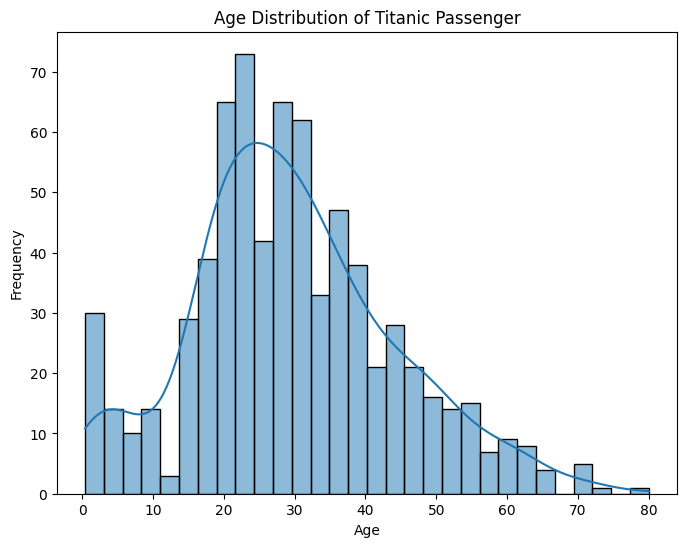

In [ ]:
print("Distribution of Age Column:")
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.histplot(df_titanic["Age"], kde = True, bins = 30)
plt.title("Age Distribution of Titanic Passenger")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()
# We will use Median as the feature values are right skewed

Distribution of Embarked Column:


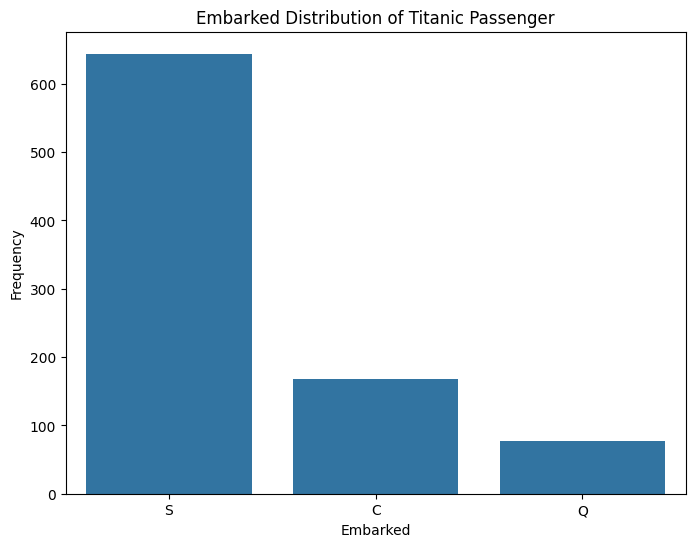

In [ ]:
print("Distribution of Embarked Column:")

plt.figure(figsize=(8,6))
sns.countplot(data = df_titanic, x= "Embarked")
plt.title("Embarked Distribution of Titanic Passenger")
plt.xlabel("Embarked")
plt.ylabel("Frequency")
plt.show()



In [ ]:
# 1. Handle numeric missing values: Age
age_median = df_titanic["Age"].median()
df_titanic["Age"] = df_titanic["Age"].fillna(age_median)

# 2. Handle Categorical missing values: Embarked
embarked_mode = df_titanic["Embarked"].mode()[0]
df_titanic["Embarked"] = df_titanic["Embarked"].fillna(embarked_mode)

# 3. Drop cabin (too many missing values)
df_titanic = df_titanic.drop(columns=["Cabin"])

In [ ]:
print("Missing values per column: ")
df_titanic.isnull().sum()

Missing values per column: 


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Load Heart Dataset
heart_path = "heart.csv"
df_heart = pd.read_csv(heart_path)

print("First 10 row of heart dataset: ")
display(df_heart.head(10))

print("\nColumn data types:")
display(df_heart.dtypes)

First 10 row of heart dataset: 


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0



Column data types:


,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


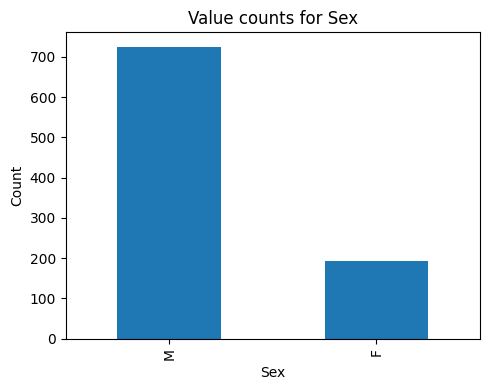

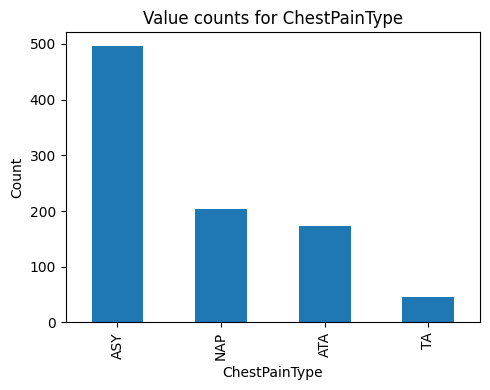

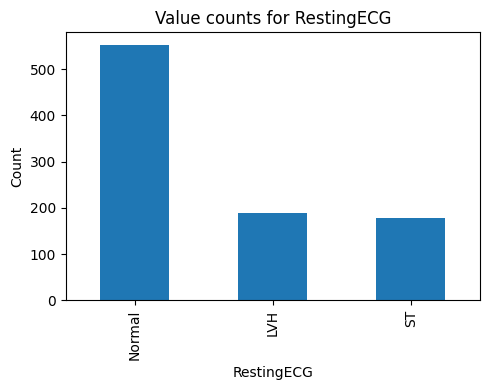

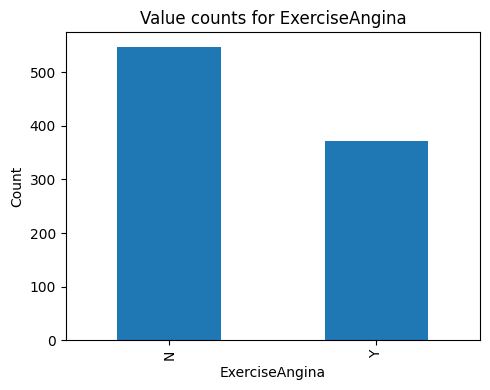

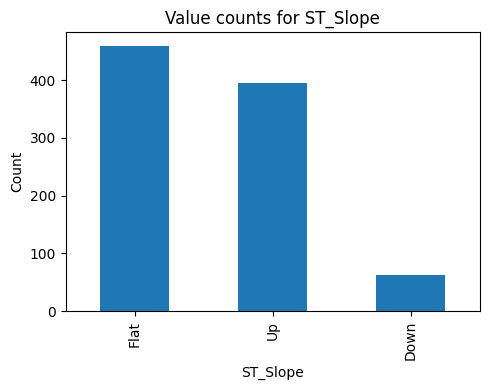

In [ ]:
# Categorical Feature Exploration

categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
for c in categorical_cols:
  plt.figure(figsize=(5,4))
  df_heart[c].value_counts().plot(kind="bar")
  plt.title(f"Value counts for {c}")
  plt.ylabel("Count")
  plt.tight_layout()
  plt.show()

In [ ]:
# Label Encoding for binary categorical columns -> Sex and ExerciseAngina

le = LabelEncoder()
df_heart["Sex"] = le.fit_transform(df_heart["Sex"])
df_heart["ExerciseAngina"] = le.fit_transform(df_heart["ExerciseAngina"])
df_heart.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,0,0.0,Up,0
5,39,1,NAP,120,339,0,Normal,170,0,0.0,Up,0
6,45,0,ATA,130,237,0,Normal,170,0,0.0,Up,0
7,54,1,ATA,110,208,0,Normal,142,0,0.0,Up,0
8,37,1,ASY,140,207,0,Normal,130,1,1.5,Flat,1
9,48,0,ATA,120,284,0,Normal,120,0,0.0,Up,0


In [ ]:
# OneHot Encoding for normal categorical columns
cat_cols = ["ChestPainType", "RestingECG", "ST_Slope"]

df_heart_encoded = pd.get_dummies(
    df_heart,
    columns = cat_cols,
    dtype = int
)

In [ ]:
df_heart.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,0,0.0,Up,0
5,39,1,NAP,120,339,0,Normal,170,0,0.0,Up,0
6,45,0,ATA,130,237,0,Normal,170,0,0.0,Up,0
7,54,1,ATA,110,208,0,Normal,142,0,0.0,Up,0
8,37,1,ASY,140,207,0,Normal,130,1,1.5,Flat,1
9,48,0,ATA,120,284,0,Normal,120,0,0.0,Up,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Assume df_heart_encoded is our working dataframe with target 'HeartDisease'
target_col = "HeartDisease"
x = df_heart_encoded.drop(columns=[target_col])
y = df_heart_encoded[target_col]

x_train, x_test, y_train, y_test  = train_test_split(x,y, test_size = .25, random_state = 42)

# Standard Scaling
scaler_sd = StandardScaler()
x_train_std = scaler_sd.fit_transform(x_train) # mean and SD will be Calculated from x_train
x_test_std = scaler_sd.transform(x_test)

# MinMax scaling
scaler_mm = MinMaxScaler()
x_train_mm = scaler_mm.fit_transform(x_train)
x_test_mm = scaler_mm.fit_transform(x_test)

print("\n--- Displaying Standard Scaled Data ---")
# Convert scaled arrays back to Dataframe for batter visualization with column names
x_train_std_df = pd.DataFrame(x_train_std, columns = x_train.columns, index = x_train.index)
x_test_std_df = pd.DataFrame(x_test_std, columns = x_test.columns, index = x_test.index)
print("\nFirst 5 rows of x_train (Standard Scaled)")
display(x_train_std_df.head())
display(x_test_std_df.head())


x_train_mm_df = pd.DataFrame(x_train_mm, columns = x_train.columns, index = x_train.index)
x_test_mm_df = pd.DataFrame(x_test_mm, columns = x_test.columns, index = x_test.index)

print("\nFirst 5 rows of x_train (Minmax Scaled)")
display(x_train_mm_df.head())
display(x_test_mm_df.head())


--- Displaying Standard Scaled Data ---

First 5 rows of x_train (Standard Scaled)


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
155,0.239292,0.537019,1.183802,1.307314,1.877849,0.551672,1.182037,1.900458,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064
362,0.239292,0.537019,1.183802,-1.878000,-0.532524,-1.486343,-0.845997,-0.834739,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,-1.225487,2.023931,-0.254981,0.962897,-0.851064
869,0.558968,0.537019,0.913811,0.096522,1.877849,0.831400,-0.845997,0.624033,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
101,-0.293501,0.537019,-0.166155,-0.210833,-0.532524,-1.446382,-0.845997,-0.834739,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
199,0.345851,-1.862131,-0.166155,0.990645,-0.532524,-1.526304,-0.845997,0.076994,-1.104244,-0.480384,-0.530275,4.683304,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
668,0.985202,-1.862131,0.373828,-0.061812,-0.532524,1.710544,-0.845997,-0.834739,-1.104244,2.081666,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
30,-0.080384,0.537019,0.643819,2.946539,-0.532524,-0.247550,-0.845997,-0.834739,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064
377,1.198319,0.537019,1.453793,-1.878000,1.877849,-0.567238,-0.845997,0.259340,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,-1.225487,2.023931,-0.254981,0.962897,-0.851064
535,0.239292,0.537019,-0.166155,-1.878000,-0.532524,-0.567238,1.182037,0.076994,0.905597,-0.480384,-0.530275,-0.213524,1.978455,-1.225487,-0.494088,-0.254981,0.962897,-0.851064
807,0.026175,0.537019,-1.354116,0.999959,-0.532524,0.791439,-0.845997,-0.834739,-1.104244,2.081666,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999



First 5 rows of x_train (Minmax Scaled)


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
155,0.562500,1.0,0.775,0.567164,1.0,0.674419,1.0,0.636364,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
362,0.562500,1.0,0.775,0.000000,0.0,0.279070,0.0,0.295455,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
869,0.625000,1.0,0.750,0.351575,1.0,0.728682,0.0,0.477273,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
101,0.458333,1.0,0.650,0.296849,0.0,0.286822,0.0,0.295455,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
199,0.583333,0.0,0.650,0.510779,0.0,0.271318,0.0,0.409091,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
668,0.729167,0.0,0.500000,0.345745,0.0,0.838028,0.0,0.215686,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
30,0.520833,1.0,0.541667,0.918440,0.0,0.492958,0.0,0.215686,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
377,0.770833,1.0,0.666667,0.000000,1.0,0.436620,0.0,0.450980,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
535,0.583333,1.0,0.416667,0.000000,0.0,0.436620,1.0,0.411765,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
807,0.541667,1.0,0.233333,0.547872,0.0,0.676056,0.0,0.215686,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


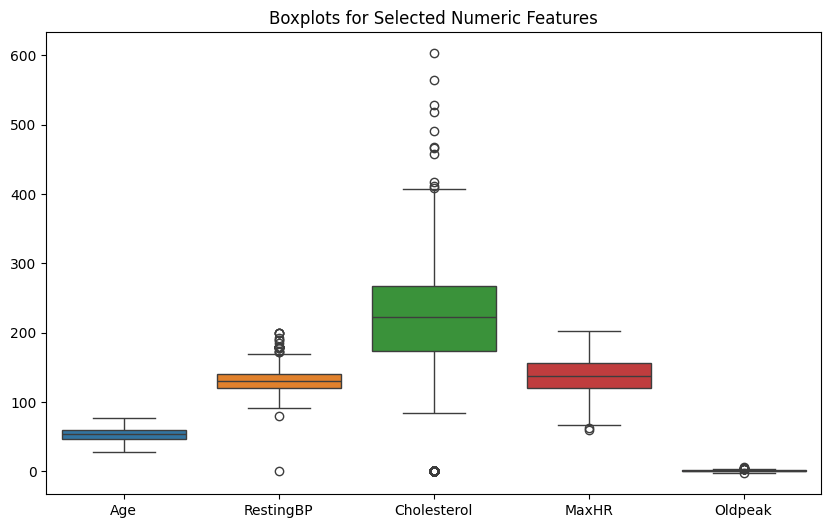

In [ ]:
numeric_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

plt.figure(figsize=(10, 6))

sns.boxplot(data=df_heart_encoded[numeric_cols])

plt.title("Boxplots for Selected Numeric Features")
plt.show()

In [ ]:
col = "Cholesterol"

Q1 = df_heart_encoded[col].quantile(0.25)
Q3 = df_heart_encoded[col].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_heart_encoded[
    (df_heart_encoded[col] < lower) |
    (df_heart_encoded[col] > upper)
]

print(f"Number of Detected Outliers in {col}: {len(outliers)}")

Number of Detected Outliers in Cholesterol: 183


In [ ]:
col = "Age"

Q1 = df_heart_encoded[col].quantile(0.25)
Q3 = df_heart_encoded[col].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_heart_encoded[
    (df_heart_encoded[col] < lower) |
    (df_heart_encoded[col] > upper)
]

print(f"Number of Detected Outliers in {col}: {len(outliers)}")

Number of Detected Outliers in Age: 0


In [ ]:
col = "RestingBP"

Q1 = df_heart_encoded[col].quantile(0.25)
Q3 = df_heart_encoded[col].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_heart_encoded[
    (df_heart_encoded[col] < lower) |
    (df_heart_encoded[col] > upper)
]

print(f"Number of Detected Outliers in {col}: {len(outliers)}")

Number of Detected Outliers in RestingBP: 28


In [ ]:
col = "MaxHR"

Q1 = df_heart_encoded[col].quantile(0.25)
Q3 = df_heart_encoded[col].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_heart_encoded[
    (df_heart_encoded[col] < lower) |
    (df_heart_encoded[col] > upper)
]

print(f"Number of Detected Outliers in {col}: {len(outliers)}")

Number of Detected Outliers in MaxHR: 2


In [ ]:
col = "Oldpeak"

Q1 = df_heart_encoded[col].quantile(0.25)
Q3 = df_heart_encoded[col].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_heart_encoded[
    (df_heart_encoded[col] < lower) |
    (df_heart_encoded[col] > upper)
]

print(f"Number of Detected Outliers in {col}: {len(outliers)}")

Number of Detected Outliers in Oldpeak: 16


In [ ]:
col = "Cholesterol"

Q1 = df_heart_encoded[col].quantile(0.25)
Q3 = df_heart_encoded[col].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_heart_encoded[
    (df_heart_encoded[col] < lower) |
    (df_heart_encoded[col] > upper)
]

print(f"Number of Detected Outliers in {col}: {len(outliers)}")

Number of Detected Outliers in Cholesterol: 183


In [ ]:
import numpy as np
# 1. Remove outliers
df_no_outliers = [(df_heart_encoded[col] >=lower) & (df_heart_encoded[col] <=upper)]
print(len(df_no_outliers))

# 2. Cap outliers
df_capped = df_heart_encoded.copy()
df_capped[col] = df_capped[col].clip(lower,upper)

print(df_capped)

# Log tranformation the column (for skewed distribution)
df_log = df_heart_encoded.copy()
df_log[col+"_log"] = np.log(df_log[col]+1)

print(df_log)


1
     Age  Sex  RestingBP  ...  ST_Slope_Down  ST_Slope_Flat  ST_Slope_Up
0     40    1        140  ...              0              0            1
1     49    0        160  ...              0              1            0
2     37    1        130  ...              0              0            1
3     48    0        138  ...              0              1            0
4     54    1        150  ...              0              0            1
..   ...  ...        ...  ...            ...            ...          ...
913   45    1        110  ...              0              1            0
914   68    1        144  ...              0              1            0
915   57    1        130  ...              0              1            0
916   57    0        130  ...              0              1            0
917   38    1        138  ...              0              0            1

[918 rows x 19 columns]
     Age  Sex  RestingBP  ...  ST_Slope_Flat  ST_Slope_Up  Cholesterol_log
0     40    1        1

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Poynomial features using Age and MaxHR (if available)
poly_cols = ["Age", "MaxHR"]
poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(df_heart_encoded[poly_cols])
poly_feature_names = poly.get_feature_names_out(poly_cols)

print(poly_feature_names)
print(poly_features.shape)

['Age' 'MaxHR' 'Age^2' 'Age MaxHR' 'MaxHR^2']
(918, 5)


In [ ]:
# Binning Age into categories (Young, Middle, Old)
df_heart_encoded["Age_bin"] = pd.cut(
    df_heart_encoded["Age"],
    bins=[0,30,50,100],
    labels=["Young","Middle","Old"]
)
print(df_heart_encoded[["Age", "Age_bin"]].head(50))

    Age Age_bin
0    40  Middle
1    49  Middle
2    37  Middle
3    48  Middle
4    54     Old
5    39  Middle
6    45  Middle
7    54     Old
8    37  Middle
9    48  Middle
10   37  Middle
11   58     Old
12   39  Middle
13   49  Middle
14   42  Middle
15   54     Old
16   38  Middle
17   43  Middle
18   60     Old
19   36  Middle
20   43  Middle
21   44  Middle
22   49  Middle
23   44  Middle
24   40  Middle
25   36  Middle
26   53     Old
27   52     Old
28   53     Old
29   51     Old
30   53     Old
31   56     Old
32   54     Old
33   41  Middle
34   43  Middle
35   32  Middle
36   65     Old
37   41  Middle
38   48  Middle
39   48  Middle
40   54     Old
41   54     Old
42   35  Middle
43   52     Old
44   43  Middle
45   59     Old
46   37  Middle
47   50  Middle
48   36  Middle
49   41  Middle


In [ ]:
df_heart_encoded["Age_bin"] = pd.cut(
    df_heart_encoded["Age"],
    bins=[0,30,50,70,100],
    labels=["Young","Middle","Middle-Old", "Old"]
)
print(df_heart_encoded[["Age", "Age_bin"]].head(50))

    Age     Age_bin
0    40      Middle
1    49      Middle
2    37      Middle
3    48      Middle
4    54  Middle-Old
5    39      Middle
6    45      Middle
7    54  Middle-Old
8    37      Middle
9    48      Middle
10   37      Middle
11   58  Middle-Old
12   39      Middle
13   49      Middle
14   42      Middle
15   54  Middle-Old
16   38      Middle
17   43      Middle
18   60  Middle-Old
19   36      Middle
20   43      Middle
21   44      Middle
22   49      Middle
23   44      Middle
24   40      Middle
25   36      Middle
26   53  Middle-Old
27   52  Middle-Old
28   53  Middle-Old
29   51  Middle-Old
30   53  Middle-Old
31   56  Middle-Old
32   54  Middle-Old
33   41      Middle
34   43      Middle
35   32      Middle
36   65  Middle-Old
37   41      Middle
38   48      Middle
39   48      Middle
40   54  Middle-Old
41   54  Middle-Old
42   35      Middle
43   52  Middle-Old
44   43      Middle
45   59  Middle-Old
46   37      Middle
47   50      Middle
48   36      Middle


In [ ]:
# Domain-driven risk categories for RestingBP and Oldpeak

def bp_risk(bp):
    if bp < 120:
        return "Normal"
    elif bp < 140:
        return "Elevated"
    else:
        return "High"

def oldpeak(op):
    if op == 0:
        return "No Stress"
    elif op < 2:
        return "Moderate Stress"
    else:
        return "High Stress"

df_heart_encoded["BP_Risk"] = df_heart_encoded["RestingBP"].apply(bp_risk)

df_heart_encoded["Oldpeak_Risk"] = df_heart_encoded["Oldpeak"].apply(oldpeak)

df_heart_encoded[["RestingBP", "BP_Risk", "Oldpeak", "Oldpeak_Risk"]]

,RestingBP,BP_Risk,Oldpeak,Oldpeak_Risk
0,140,High,0.0,No Stress
1,160,High,1.0,Moderate Stress
2,130,Elevated,0.0,No Stress
3,138,Elevated,1.5,Moderate Stress
4,150,High,0.0,No Stress
...,...,...,...,...
913,110,Normal,1.2,Moderate Stress
914,144,High,3.4,High Stress
915,130,Elevated,1.2,Moderate Stress
916,130,Elevated,0.0,No Stress


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder


# Define numeric and categorical columns for the pipeline
num_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
cat_features = ["Sex", "ExerciseAngina", "ChestPainType", "RestingECG", "ST_Slope"]

# Numeric pipeline
num_pipeline = Pipeline([
    ("scaler",StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ("ohe", OneHotEncoder(drop="first"))
])

# Combine both
preprocess = ColumnTransformer([
    ("num",num_pipeline, num_features),
    ("cat", cat_pipeline,cat_features )
])

# Full pipeline with simple model
clf = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=1000))
])


In [ ]:
# Train-test split using original df_heart (not already encoded)

X = df_heart.drop(columns=[target_col])
y = df_heart[target_col]

x_train_pipe, x_test_pipe, y_train_pipe, y_test_pipe = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Fit the full pipeline
clf.fit(x_train_pipe, y_train_pipe)

# Predict and evaluate
from sklearn.metrics import accuracy_score

y_pred_pipe = clf.predict(x_test_pipe)

acc = accuracy_score(y_test_pipe, y_pred_pipe)

print("Logistic Regression with preprocessing pipeline:", acc)

Logistic Regression with preprocessing pipeline: 0.8434782608695652


In [ ]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [ ]:
# Create a Simple Dataset
hours = np.array([2, 4, 6, 8, 10]).reshape(-1, 1)
marks = np.array([55, 60, 70, 80, 88])
hours, marks

(array([[ 2],
        [ 4],
        [ 6],
        [ 8],
        [10]]),
 array([55, 60, 70, 80, 88]))

In [ ]:
# Train a Linear Regression Model
model = LinearRegression()
model.fit(hours, marks)

LinearRegression()

In [ ]:
# View the Learned Parameters
print("m: ", model.coef_[0])
print("c: ", model.intercept_)
# marks = 4.3xhours + 44.8

m:  4.3
c:  44.8


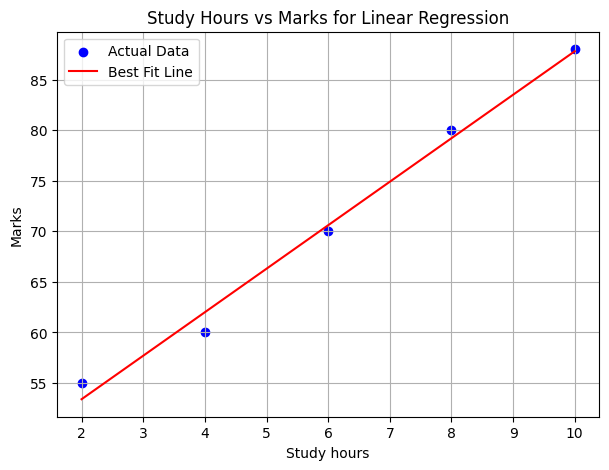

In [ ]:
# Visualize the best fit line
plt.scatter(hours, marks, color='blue', label="Actual Data")
predicted_marks = model.predict(hours)
plt.plot(hours, predicted_marks, color='red', label="Best Fit Line")

plt.xlabel("Study hours")
plt.ylabel("Marks")

plt.title("Study Hours vs Marks for Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Predict Marks for a new Student
new_hours = np.array([[7]])
prediction = model.predict(new_hours)
print("Predicted Marks: ", prediction[0])

Predicted Marks:  74.89999999999999


In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error

In [ ]:
# Creat the examle dataset
hours = np.array([2, 4, 6, 8, 10]).reshape(-1, 1)
marks = np.array([55, 60, 70, 80, 88])
hours, marks

(array([[ 2],
        [ 4],
        [ 6],
        [ 8],
        [10]]),
 array([55, 60, 70, 80, 88]))

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(hours, marks)
print("m: ", lin_reg.coef_[0])
print("c: ", lin_reg.intercept_)

m:  4.3
c:  44.8


In [ ]:
# Use a Grediant-Des
sgd_reg = SGDRegressor(
    max_iter = 1000,
    learning_rate = "invscaling",
    eta0=0.01,
    random_state=42
)
sgd_reg.fit(hours, marks)
print("m: ",sgd_reg.coef_[0])
print("c: ", sgd_reg.intercept_[0])

pred_sgd = sgd_reg.predict(hours)
mse_sgd = mean_squared_error(marks,pred_sgd)

print("MSE of SGDRegressor: ", mse_sgd)

m:  5.698065492806587
c:  34.475265427340794
MSE of SGDRegressor:  20.906115830567398


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


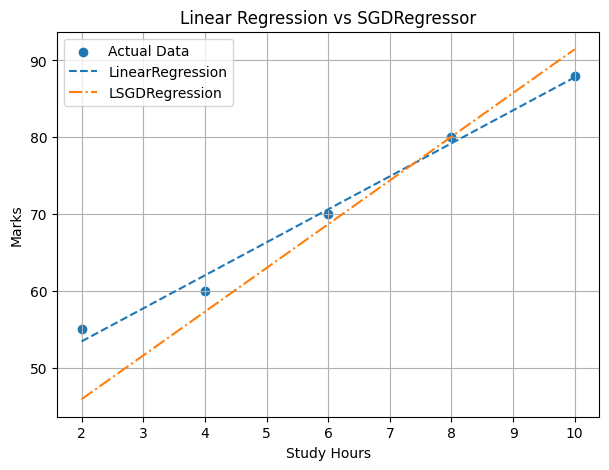

In [ ]:
# Compare Both Lines Visually
plt.scatter(hours, marks, label="Actual Data")

plt.plot(hours, predicted_marks, label="LinearRegression", linestyle="--")
plt.plot(hours, pred_sgd, label="LSGDRegression", linestyle="-.")

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Linear Regression vs SGDRegressor")
plt.legend()
plt.grid(True)
plt.show()

**Regression Evaluation Matrix(R², MAE, MSE, RMSE)**

In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Fit linear Regression
model= LinearRegression()
model.fit(hours,marks)
pred = model.predict(hours)
print(pred)

[53.4 62.  70.6 79.2 87.8]


In [ ]:
mae = mean_absolute_error(marks, pred)
mse = mean_squared_error(marks, pred)
rmse = np.sqrt(mse)
r2 = r2_score(marks, pred)

In [ ]:
#print Result
print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R²: ", r2)

MAE:  1.040000000000002
MSE:  1.5200000000000033
RMSE:  1.2328828005937966
R²:  0.9898286937901499


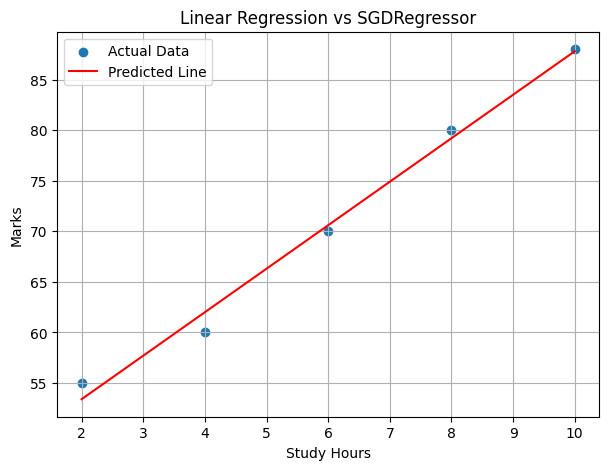

In [ ]:
plt.scatter(hours, marks, label="Actual Data")

plt.plot(hours, pred,color="red", label="Predicted Line")

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Linear Regression vs SGDRegressor")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import(
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
)
# Make plots a bit large by default
plt.rcParams['figure.figsize'] = (7,5)

In [ ]:
# Create a small synthetic dataset
data = {
    'weather': ['Sunny', 'Rainy', 'Sunny','Sunny', 'Rainy','Rainy', 'Sunny','Rainy'],
    'windy': [0,1,0,1,0,1,0,1],
    'play': [1,0,1,1,0,0,1,0]
}
df_synthetic = pd.DataFrame(data)
df_synthetic

,weather,windy,play
0,Sunny,0,1
1,Rainy,1,0
2,Sunny,0,1
3,Sunny,1,1
4,Rainy,0,0
5,Rainy,1,0
6,Sunny,0,1
7,Rainy,1,0


In [ ]:
# Encode categorical feature and prepare x,y
df_synthetic['weather_num'] = df_synthetic['weather'].map({'Sunny':1, 'Rainy':0})
x_syn = df_synthetic[['weather_num', 'windy']]
y_syn = df_synthetic['play']
print(x_syn)
print(y_syn)

   weather_num  windy
0            1      0
1            0      1
2            1      0
3            1      1
4            0      0
5            0      1
6            1      0
7            0      1
0    1
1    0
2    1
3    1
4    0
5    0
6    1
7    0
Name: play, dtype: int64


In [ ]:
# Train a simple decision tree
tree_syn = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_syn.fit(x_syn, y_syn)
tree_syn


DecisionTreeClassifier(max_depth=3, random_state=42)

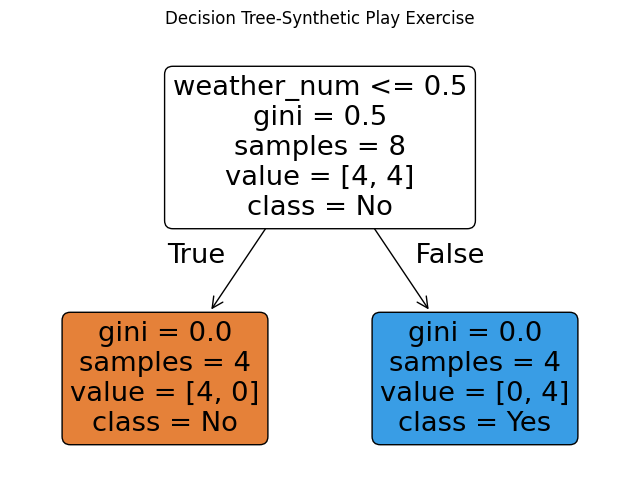

In [ ]:
# Visualize the tree
plt.figure(figsize=(8,6))
plot_tree(
    tree_syn,
    feature_names = ['weather_num', 'windy'],
    class_names = ['No', 'Yes'],
    filled = True,
    rounded = True,
)
plt.title("Decision Tree-Synthetic Play Exercise")
plt.show()

In [ ]:
# Example: Sunny (1), not windy (0)
example_1 = pd.DataFrame([[1, 0]], columns=['weather_num', 'windy'])
pred_1 = tree_syn.predict(example_1)[0]
print('Sunny, not windy -> play prediction:', pred_1)

# Example: Rainy (0), windy (1)
example_2 = pd.DataFrame([[0, 1]], columns=['weather_num', 'windy'])
pred_2 = tree_syn.predict(example_2)[0]
print('Rainy, windy -> play prediction:', pred_2)

Sunny, not windy -> play prediction: 1
Rainy, windy -> play prediction: 0


In [ ]:
# Create a slightly larger synthetic dataset
from sklearn.datasets import make_classification

x_big, y_big = make_classification(
  n_samples = 400,
  n_features = 5,
  n_informative = 3,
  n_redundant = 0,
  n_classes=2,
  random_state=42,
  )

x_train_big, x_test_big, y_train_big, y_test_big = train_test_split(
    x_big, y_big, test_size = 0.3, random_state=42
)
x_train_big.shape, x_test_big.shape

((280, 5), (120, 5))

In [ ]:
deep_tree = DecisionTreeClassifier(random_state=42)
deep_tree.fit(x_train_big, y_train_big)

pruned_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
pruned_tree.fit(x_train_big, y_train_big)

y_train_pred_deep = deep_tree.predict(x_train_big)
y_test_pred_deep = deep_tree.predict(x_test_big)

y_train_pred_pruned = pruned_tree.predict(x_train_big)
y_test_pred_pruned = pruned_tree.predict(x_test_big)

print('Deep tree - train accuracy:', round(accuracy_score(y_train_big, y_train_pred_deep),3))
print('Deep tree - train accuracy:', round(accuracy_score(y_test_big, y_test_pred_deep),3))
print()
print('Pruned tree - train accuracy:', round(accuracy_score(y_train_big, y_train_pred_pruned),3))
print('Pruned tree - train accuracy:', round(accuracy_score(y_test_big, y_test_pred_pruned),3))

Deep tree - train accuracy: 1.0
Deep tree - train accuracy: 0.883

Pruned tree - train accuracy: 0.904
Pruned tree - train accuracy: 0.892


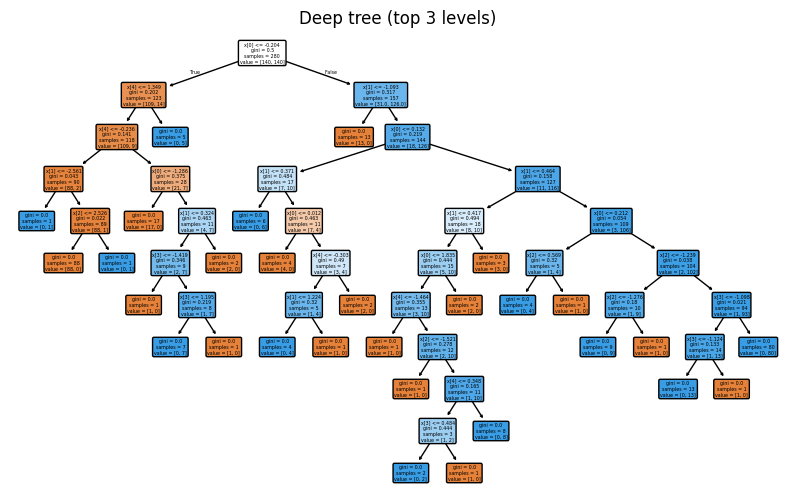

In [ ]:
# Plot deep tree (Full)
plt.figure(figsize=(10,6))
plot_tree(deep_tree, filled=True, rounded= True)
plt.title("Deep tree (top 3 levels)")
plt.show()

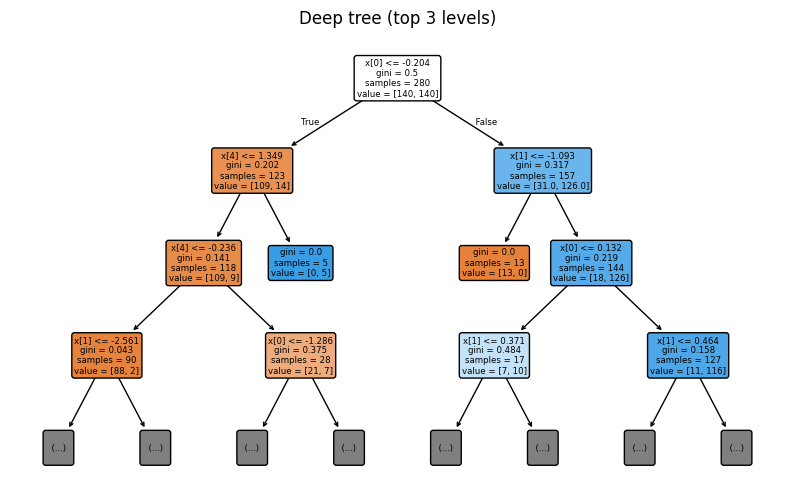

In [ ]:
# Plot deep tree (showing only top levels for readability)
plt.figure(figsize=(10,6))
plot_tree(deep_tree, filled=True, rounded= True, max_depth=3)
plt.title("Deep tree (top 3 levels)")
plt.show()

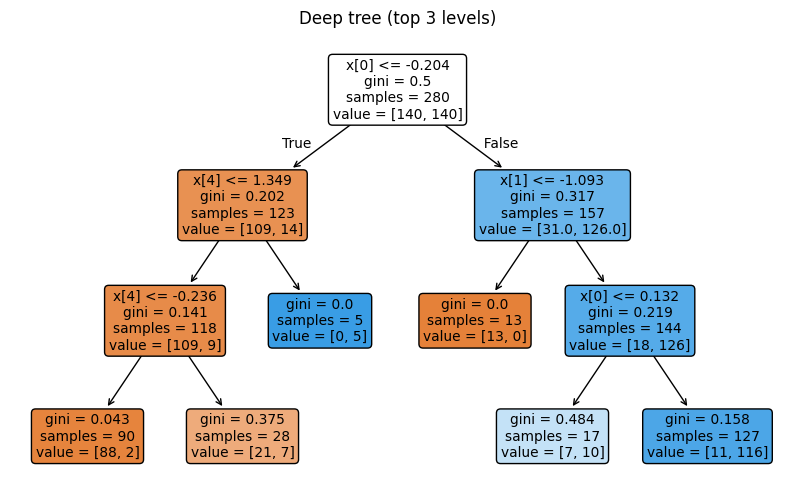

In [ ]:
# Plot pruned tree (showing only top levels for readability)
plt.figure(figsize=(10,6))
plot_tree(pruned_tree, filled=True, rounded= True, max_depth=3)
plt.title("Deep tree (top 3 levels)")
plt.show()

In [ ]:
np.random.seed(42)
n_samples = 300

age = np.random.randint(30, 80, size = n_samples)
chol = np.random.randint(150, 300, size = n_samples)
thalach = np.random.randint(90, 200, size = n_samples)

# We create a simple rule-based probability for disease. just for realism
risk_score = 0.03 * (age - 40) + 0.02 * (chol - 200) -0.02 * (thalach - 140)
prob = 1/(1+np.exp(-0.05 * risk_score))

target = (prob>np.median(prob)).astype(int)

df_heart = pd.DataFrame({
    'age': age,
    'chol': chol,
    'thalach': thalach,
    'target': target
})
df_heart.head()

,age,chol,thalach,target
0,68,253,128,1
1,58,233,90,1
2,44,261,92,1
3,72,248,166,1
4,37,242,181,0


In [ ]:
# Train-test split and model training
x_heart = df_heart[['age','chol','thalach']]
y_heart = df_heart[['target']]

x_train_h, x_test_h, y_train_h, y_test_h = train_test_split(
    x_heart, y_heart, test_size=0.2, random_state=42
)

tree_heart = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_heart.fit(x_train_h, y_train_h)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
# Confusion metrix
y_pred_h = tree_heart.predict(x_test_h)

cm = confusion_matrix(y_test_h, y_pred_h)
print(cm)

[[23  3]
 [ 6 28]]


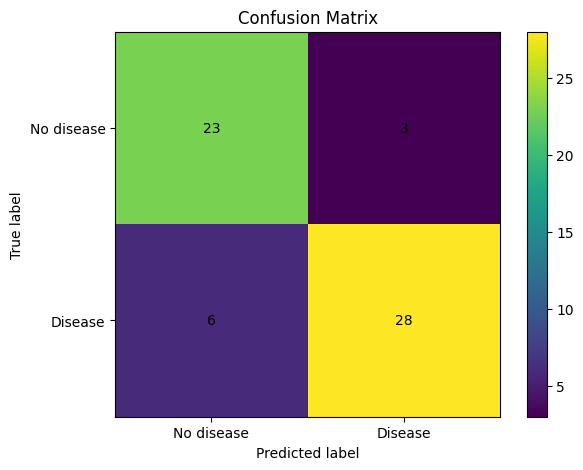

In [ ]:
# Plot of confusion matrix
fig, ax = plt.subplots()
im = ax.imshow(cm, interpolation= 'nearest')
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

# Show all tricks and label them
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(["No disease", 'Disease'])
ax.set_yticklabels(["No disease", 'Disease'])

# Loop over data dimensions and create text annotations.
for i in range(cm.shape[0]):
  for j in range(cm.shape[1]):
    ax.text(j,i,cm[i,j], ha= 'center', va='center')

plt.colorbar(im)
plt.show()

In [ ]:
# Accuracy, precision, recall, F1
acc = accuracy_score(y_test_h, y_pred_h)
prec = precision_score(y_test_h, y_pred_h)
rec = recall_score(y_test_h, y_pred_h)
f1 = f1_score(y_test_h, y_pred_h)

print('Accuracy :', round(acc, 3))
print('Precision :', round(prec, 3))
print('Accuracy :', round(rec, 3))
print('Accuracy :', round(f1, 3))

Accuracy : 0.85
Precision : 0.903
Accuracy : 0.824
Accuracy : 0.862


**ROC Curve, AUC, and Thewshold Interpretation**

In [ ]:
# Predicted probabilities
y_proba_h = tree_heart.predict_proba(x_test_h)[:,1]
y_proba_h[:10]

array([0.875     , 0.        , 0.04761905, 0.        , 0.875     ,
       1.        , 1.        , 1.        , 1.        , 0.        ])

In [ ]:
# ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_h, y_proba_h)
roc_auc = auc(fpr,tpr)
print('AUC: ', round(roc_auc,3))

AUC:  0.925


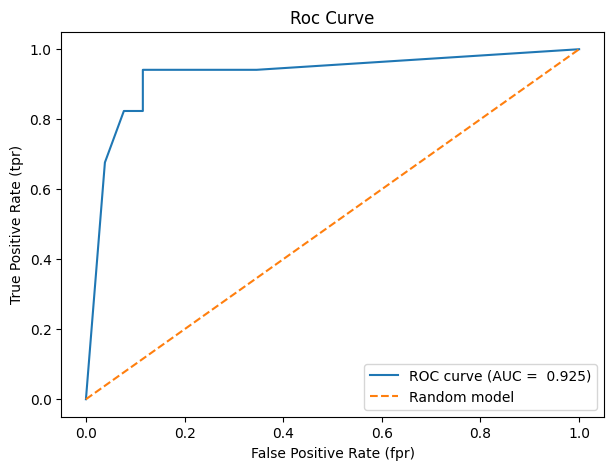

In [ ]:
# Plot
plt.figure()
plt.plot(fpr,tpr, label = f'ROC curve (AUC = {roc_auc: .3f})')
plt.plot([0,1], [0,1],linestyle ='--', label= 'Random model')
plt.xlabel('False Positive Rate (fpr)')
plt.ylabel('True Positive Rate (tpr)')
plt.title("Roc Curve")
plt.legend()
plt.show()